# 3ptWL-cov Example

This notebook shows a compact covariance-matrix workflow using the helper functions in `tests/python/covariance_example.py`.  It reads the bundled `C_ell` table, builds a small covariance mask, runs `wlcovpy`, and saves publication-style diagnostic plots in `tests/notebooks/plots/`.

The default settings are intentionally small so the example is useful for documentation and quick tests.  The final section explains how to scale the same workflow to the larger R2D2-style configuration.

## 1. Setup

Run this notebook from anywhere inside the repository.  The setup cell finds the repository root, imports `covariance_example.py`, and creates the local `plots/` directory.

In [5]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import numpy as np


def find_repo_root(start=Path.cwd()):
    for path in (start, *start.parents):
        if (path / "tests" / "python" / "covariance_example.py").exists():
            return path
    raise RuntimeError("Run this notebook from inside the 3ptWL-cov repository.")


REPO_ROOT = find_repo_root()
NOTEBOOK_DIR = REPO_ROOT / "tests" / "notebooks"
PLOTS_DIR = NOTEBOOK_DIR / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(REPO_ROOT / "tests" / "python"))
import covariance_example as cov

# Keep temporary files and outputs local to tests/notebooks/.
os.chdir(NOTEBOOK_DIR)

CLS_FILE = REPO_ROOT / "tests" / "input" / "Cls_ep2.txt"
THETA_FILE = REPO_ROOT / "tests" / "input" / "theta_array.txt"

print(f"Repository root: {REPO_ROOT}")
print(f"Plot directory:   {PLOTS_DIR}")

Repository root: /home/sadi/LSST/3ptWL-cov
Plot directory:   /home/sadi/LSST/3ptWL-cov/tests/notebooks/plots


## 2. Helper Function Map

`covariance_example.py` keeps the notebook short by packaging the repeated steps: `add_noise_to_column` writes a temporary noisy `C_ell` table, `build_mask` selects the covariance entries to compute, `get_valid_indices` converts that mask into index pairs, `calculate_integral` runs one `wlcovpy` calculation, and `compute_cov_noise` assembles the symmetric matrix.

## 3. Inspect the Inputs

`wlcov` expects a two-column angular power-spectrum table, `ell` and `C_ell`.  The covariance workflow also needs an angular grid.  Here we use the first four angular values to keep the example fast.

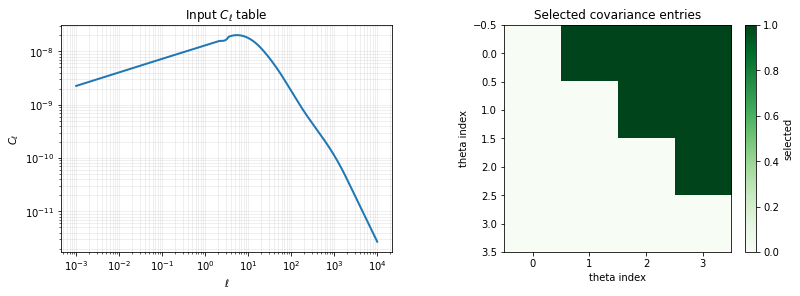

In [6]:
ell, cls = np.loadtxt(CLS_FILE, unpack=True)
theta_all = np.loadtxt(THETA_FILE)

theta = theta_all[:4]
rows = 0
diagonals = 1
mask = cov.build_mask(dim=len(theta), rows=rows, diagonals=diagonals)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)

axes[0].loglog(ell, cls, color="#1f77b4", lw=2)
axes[0].set_title(r"Input $C_\ell$ table")
axes[0].set_xlabel(r"$\ell$")
axes[0].set_ylabel(r"$C_\ell$")
axes[0].grid(True, which="both", alpha=0.25)

im = axes[1].imshow(mask, cmap="Greens", interpolation="nearest")
axes[1].set_title("Selected covariance entries")
axes[1].set_xlabel("theta index")
axes[1].set_ylabel("theta index")
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04, label="selected")

fig.savefig(PLOTS_DIR / "inputs_and_mask.png", dpi=300, bbox_inches="tight")
plt.show()

## 4. Compute a Compact Covariance Matrix

The helper adds a small noise term to the input spectrum, runs the covariance integral for the selected entries, and stores the resulting matrix.  This cell uses a low `ppp` value because the goal is a quick documentation example, not a convergence-grade production run.

In [7]:
settings = dict(
    rows=rows,
    diagonals=diagonals,
    dim=len(theta),
    m=0,
    mp=0,
    ppp=4,
    noise=6.1e-11,
)

covariance = cov.compute_cov_noise(
    thtdata=theta,
    inputfile=CLS_FILE,
    outputfile=NOTEBOOK_DIR / "analytic_covariance_example.txt",
    **settings,
)

# covariance_example.py creates this temporary file in the working directory.
temp_file = NOTEBOOK_DIR / "Cls_temp.txt"
if temp_file.exists():
    temp_file.unlink()

print(f"Covariance shape: {covariance.shape}")
print(f"Finite values:    {np.isfinite(covariance).all()}")

Progress: 0/6
Progress: 5/6
Saving covariance matrix to: /home/sadi/LSST/3ptWL-cov/tests/notebooks/analytic_covariance_example.txt
Covariance shape: (6, 6)
Finite values:    True


## 5. Plot and Save the Result

The main diagnostic plot is saved to `tests/notebooks/plots/covariance_summary.png`.  The heat map shows `log10(abs(covariance))`; the right panel shows the magnitude of the upper-triangle entries.

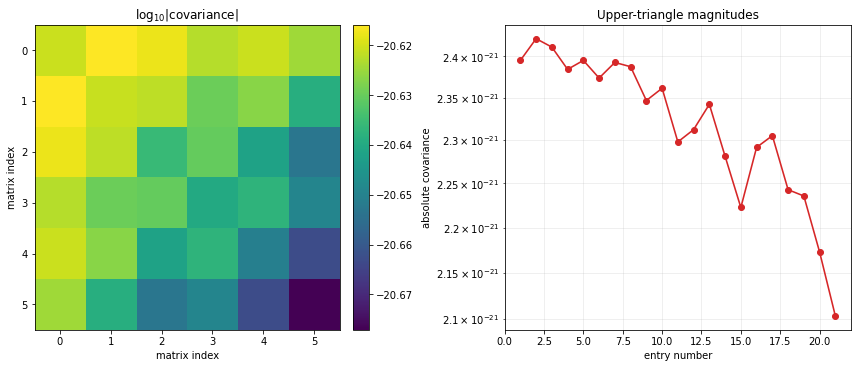

Saved: tests/notebooks/plots/covariance_summary.png


In [8]:
abs_cov = np.abs(covariance)
log_cov = np.full_like(abs_cov, np.nan, dtype=float)
positive = abs_cov > 0
log_cov[positive] = np.log10(abs_cov[positive])

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

im = axes[0].imshow(log_cov, cmap="viridis", interpolation="nearest")
axes[0].set_title(r"$\log_{10}|\mathrm{covariance}|$")
axes[0].set_xlabel("matrix index")
axes[0].set_ylabel("matrix index")
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

upper_values = abs_cov[np.triu_indices_from(abs_cov)]
upper_values = upper_values[upper_values > 0]
axes[1].semilogy(np.arange(1, len(upper_values) + 1), upper_values, "o-", color="#d62728", lw=1.6)
axes[1].set_title("Upper-triangle magnitudes")
axes[1].set_xlabel("entry number")
axes[1].set_ylabel("absolute covariance")
axes[1].grid(True, which="both", alpha=0.25)

fig.savefig(PLOTS_DIR / "covariance_summary.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {(PLOTS_DIR / 'covariance_summary.png').relative_to(REPO_ROOT)}")

## 6. R2D2 Paper-Data Reproduction Workflow

The R2D2 workflow reproduces the covariance data used in the original paper. For that production-reference case, switch to the full theta array and use settings like:

```python
theta = theta_all
settings = dict(rows=7, diagonals=4, dim=20, m=2, mp=2, ppp=20, noise=6.1e-11)
```

That run is more appropriate for validation and comparison with the paper-data reference results.  The compact example above is meant to document the workflow and verify that the code, wrapper, and plotting pipeline are connected.